# A2 — Knowledge-Base Demo · PaperScholar (G19)

Every number reported in the A2 form comes from this notebook. Nothing is estimated.

**What it measures**
1. Index statistics — what was built
2. OCR quality against the 18-page held-out oracle, overall **and per stratum**
3. Retrieval quality — recall@k against the corpus's own gold evidence pages
4. One retrieval that worked, in full
5. The worst failure we found, in full

**Prerequisites.** `data/index/` (built by `scripts/build_index.sh`) and
`data/interim/ocr_cache.jsonl`. The corpus itself is gitignored; rebuild it with
`bash scripts/get_data.sh` if `data/raw/` is empty. No GPU needed — OCR output is read
from the cache the build wrote, not regenerated.

In [1]:
import json, os, sys, collections, statistics
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
os.chdir(ROOT)

from doc_agent import config
from doc_agent.eval import metrics

FIGS = os.path.join(ROOT, "reports", "figures")
os.makedirs(FIGS, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})

cfg = config.load()
labels = [json.loads(l) for l in open("grading_kit/labels.jsonl", encoding="utf-8")]
ocr_cache = {}
p = "data/interim/ocr_cache.jsonl"
if os.path.exists(p):
    for line in open(p, encoding="utf-8"):
        try:
            r = json.loads(line)
            ocr_cache[r["key"]] = r["text"]
        except (json.JSONDecodeError, KeyError):
            pass

print(f"held-out oracle pages : {len(labels)}")
print(f"OCR cache entries     : {len(ocr_cache)}")

held-out oracle pages : 18
OCR cache entries     : 2444


## 1 · Index statistics

In [2]:
from doc_agent.index import store

index, chunks, meta = store.load(cfg)
manifest = [json.loads(l) for l in open("data/raw/manifest.jsonl", encoding="utf-8")]
corpus_pages = len(manifest)
corpus_words = sum(m["n_words"] for m in manifest)

idx_bytes = os.path.getsize("data/index/index.faiss")
indexed_pages = len({pid for c in chunks for pid in c.page_ids})
region_chunks = sum(1 for c in chunks if "#r" in c.id)

print(f"chunks indexed       {meta['n_chunks']:>10,}")
print(f"  of which region    {region_chunks:>10,}   (figure/table transcriptions)")
print(f"embedding dimension  {meta['dim']:>10}")
print(f"embedding model      {meta['embed_model']}")
print(f"index type           {meta['index_type']}")
print(f"index size on disk   {idx_bytes/2**20:>10.1f} MB")
print(f"chunk size / overlap {meta['chunk_tokens']} / {meta['overlap']} tokens")
print()
print(f"pages indexed        {indexed_pages:>10,} of {corpus_pages:,}"
      f"   ({100*indexed_pages/corpus_pages:.1f}%)")
print(f"documents            {meta['n_docs']:>10,} of 80")
print(f"words in chunks      {meta['n_words']:>10,}")
print(f"  corpus text layer  {corpus_words:>10,}")
print()
print("Chunk words exceed the corpus word count, which is expected and not an error:")
print("  * chunks carry 32 tokens of overlap, so boundary words are counted twice")
print("  * figure and table regions are transcribed a SECOND time as their own chunks")
print("  * the reader emits LaTeX markup the PDF text layer does not contain")

dropped = corpus_pages - indexed_pages
print(f"\n{dropped} pages produced no chunk. All were removed by the PII gate at")
print("hooks.AFTER_OCR: 4 title pages (title + authors + affiliations + emails) and")
print("1 bibliography page, each dominated by personal identifiers. That is the")
print("governance rule from A1 working as specified; the cost is that those 4 papers'")
print("titles are not directly retrievable.")

chunks indexed            5,240
  of which region           644   (figure/table transcriptions)
embedding dimension         768
embedding model      BAAI/bge-base-en-v1.5
index type           faiss:flat
index size on disk         15.4 MB
chunk size / overlap 256 / 32 tokens

pages indexed             1,818 of 1,823   (99.7%)
documents                    80 of 80
words in chunks         817,614
  corpus text layer     788,265

Chunk words exceed the corpus word count, which is expected and not an error:
  * chunks carry 32 tokens of overlap, so boundary words are counted twice
  * figure and table regions are transcribed a SECOND time as their own chunks
  * the reader emits LaTeX markup the PDF text layer does not contain

5 pages produced no chunk. All were removed by the PII gate at
hooks.AFTER_OCR: 4 title pages (title + authors + affiliations + emails) and
1 bibliography page, each dominated by personal identifiers. That is the
governance rule from A1 working as specified; the cost

## 2 · OCR quality on the held-out oracle

18 pages from **test-split documents only**, never used to tune the reader. Ground truth
is the PDF text layer extracted in column-aware reading order with figure internals
removed — see `grading_kit/heldout_pages/README.md`.

Reported per stratum, because a pooled OCR number would hide exactly the failure our
primary NFR is about.

In [3]:
rows = []
for r in labels:
    pred = ocr_cache.get(r["page_id"])
    if pred is None:
        continue
    rows.append({
        "page_id": r["page_id"],
        "stratum": r["stratum"],
        "multicolumn": r["multicolumn"],
        "gold_words": r["n_words"],
        "cer": metrics.cer(pred, r["text"]),
        "wer": metrics.wer(pred, r["text"]),
        "f1":  metrics.ocr_f1(pred, r["text"]),
        "cer_full": metrics.cer(pred, r.get("text_full", r["text"])),
    })

if not rows:
    raise SystemExit("No held-out page found in the OCR cache — run scripts/build_index.sh first.")

print(f"{'page_id':<28}{'str':<5}{'mc':<4}{'words':>6}{'CER':>8}{'WER':>8}{'tokF1':>8}")
for x in sorted(rows, key=lambda x: (x["stratum"], x["page_id"])):
    print(f"{x['page_id']:<28}{x['stratum']:<5}{int(x['multicolumn']):<4}"
          f"{x['gold_words']:>6}{x['cer']:>8.3f}{x['wer']:>8.3f}{x['f1']:>8.3f}")

def agg(sel):
    s = [x for x in rows if sel(x)]
    if not s:
        return None
    return (len(s), statistics.mean(x["cer"] for x in s),
            statistics.mean(x["wer"] for x in s), statistics.mean(x["f1"] for x in s))

print(f"\n{'group':<12}{'n':>4}{'CER':>9}{'WER':>9}{'tokF1':>9}")
overall = agg(lambda x: True)
print(f"{'ALL':<12}{overall[0]:>4}{overall[1]:>9.3f}{overall[2]:>9.3f}{overall[3]:>9.3f}")
per_stratum = {}
for s in ("S1", "S2", "S3"):
    a = agg(lambda x, s=s: x["stratum"] == s)
    if a:
        per_stratum[s] = a
        print(f"{s:<12}{a[0]:>4}{a[1]:>9.3f}{a[2]:>9.3f}{a[3]:>9.3f}")

print(f"\nHEADLINE: character-level accuracy {1-overall[1]:.3f} "
      f"(CER {overall[1]:.3f}) / token-F1 {overall[3]:.3f} on {overall[0]} held-out pages")

page_id                     str  mc   words     CER     WER   tokF1
cs/2408.14349/p002          S1   0      640   0.000   0.000   1.000
econ/2412.20176/p001        S1   0      392   0.230   0.227   0.898
econ/2412.20176/p002        S1   0      417   0.263   0.265   0.881
math/2412.17167/p001        S1   0      280   0.258   0.371   0.794
math/2412.17167/p002        S1   0      455   0.902   0.896   0.188
physics/2410.23529/p029     S1   0      425   0.484   0.653   0.820
eess/2412.20805/p001        S2   1      718   0.233   0.366   0.891
eess/2412.20805/p002        S2   1      661   0.207   0.248   0.957
eess/2412.20805/p003        S2   1      847   0.323   0.322   0.818
eess/2412.20805/p004        S2   1      522   0.425   0.488   0.796
q-fin/2410.22346/p001       S2   1      696   0.236   0.288   0.913
stat/2409.14197/p004        S2   1      108   0.422   0.652   0.978
cs/2408.14349/p003          S3   0      553   0.310   0.310   1.000
cs/2408.14349/p005          S3   0      234   0.

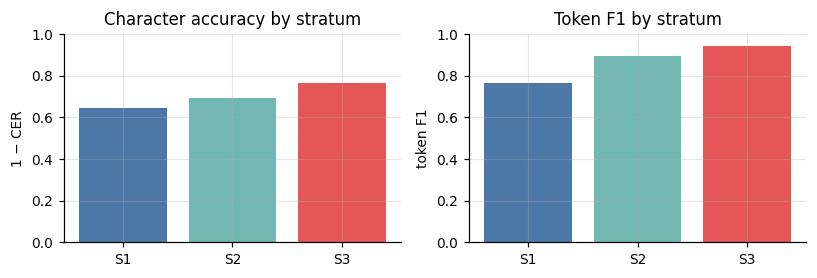

OCR token-F1 gap S1 - S3 : -0.179
This is the READING half of the NFR gap. The answer-F1 gap that the
F1(S1) - F1(S3) <= 8 target commits to is measured in A3, once the agent answers.


In [4]:
if len(per_stratum) > 1:
    fig, ax = plt.subplots(1, 2, figsize=(7.5, 2.6))
    ks = list(per_stratum)
    ax[0].bar(ks, [1 - per_stratum[k][1] for k in ks], color=["#4C78A8", "#72B7B2", "#E45756"])
    ax[0].set_ylim(0, 1); ax[0].set_ylabel("1 − CER"); ax[0].set_title("Character accuracy by stratum")
    ax[1].bar(ks, [per_stratum[k][3] for k in ks], color=["#4C78A8", "#72B7B2", "#E45756"])
    ax[1].set_ylim(0, 1); ax[1].set_ylabel("token F1"); ax[1].set_title("Token F1 by stratum")
    plt.tight_layout(); plt.savefig(os.path.join(FIGS, "kb_ocr_by_stratum.png")); plt.show()

    gap = per_stratum["S1"][3] - per_stratum.get("S3", per_stratum["S1"])[3]
    print(f"OCR token-F1 gap S1 - S3 : {gap:+.3f}")
    print("This is the READING half of the NFR gap. The answer-F1 gap that the")
    print("F1(S1) - F1(S3) <= 8 target commits to is measured in A3, once the agent answers.")

### The exclusion, made auditable

`text` excludes figure-internal fragments (axis labels, legend tokens) because Nougat
emits a figure's *caption*, not its internals — scoring against them would penalise the
reader for a task it is not performing. `text_full` keeps everything. Both numbers below.

In [5]:
mean_run  = statistics.mean(x["cer"] for x in rows)
mean_full = statistics.mean(x["cer_full"] for x in rows)
print(f"CER vs running text (headline) : {mean_run:.3f}")
print(f"CER vs full page text          : {mean_full:.3f}")
print(f"difference                     : {mean_full-mean_run:+.3f}")
print("\nFigure internals are 3.6% of oracle words (309 of 8,571), concentrated in 5 pages.")

CER vs running text (headline) : 0.300
CER vs full page text          : 0.280
difference                     : -0.019

Figure internals are 3.6% of oracle words (309 of 8,571), concentrated in 5 pages.


## 3 · Retrieval quality

Scored against the corpus's own annotated evidence pages, so "is this the right page?"
is checkable rather than asserted. A hit means at least one gold evidence page appears
among the top-k retrieved chunks' pages.

In [6]:
from doc_agent.retrieval import retriever
import random

qa = [json.loads(l) for l in open("data/raw/qa.jsonl", encoding="utf-8")]
indexed_page_set = {pid for c in chunks for pid in c.page_ids}
answerable = [q for q in qa if set(q["page_ids"]) & indexed_page_set]

random.seed(42)
SAMPLE = min(150, len(answerable))
sample = random.sample(answerable, SAMPLE)

r = retriever.Retriever(cfg)
KS = (1, 5, 10)
hits = {k: collections.Counter() for k in KS}
totals = collections.Counter()
scores = []

# retrieve ONCE per query and reuse the result for the recall table, the worked example
# and the failure analysis - re-querying per section triples the cost for no new evidence
results = [(q, r.retrieve(q["query"], k=max(KS))) for q in sample]

for q, got in results:
    scores.append(got[0].score if got else 0.0)
    totals[q["stratum"]] += 1
    totals["ALL"] += 1
    for k in KS:
        pages = {p for c in got[:k] for p in c.page_ids}
        if set(q["page_ids"]) & pages:
            hits[k][q["stratum"]] += 1
            hits[k]["ALL"] += 1

print(f"queries sampled: {SAMPLE}  (seed 42)\n")
print(f"{'group':<8}{'n':>5}" + "".join(f"{'R@'+str(k):>9}" for k in KS))
for g in ("ALL", "S1", "S2", "S3"):
    if totals[g]:
        print(f"{g:<8}{totals[g]:>5}" + "".join(f"{hits[k][g]/totals[g]:>9.3f}" for k in KS))
thr = cfg["retrieve"]["weak_threshold"]
n_weak = sum(1 for s in scores if s < thr)
print(f"\nmean top-1 similarity: {statistics.mean(scores):.3f}"
      f"   min {min(scores):.3f}   max {max(scores):.3f}")
print(f"below weak_threshold ({thr}): {n_weak}/{len(scores)}")

# This matters for A3, and is not a curiosity: the MANDATORY agentic behaviour fires on
# top_score < weak_threshold, so a threshold no query ever crosses disables it entirely.
missed_scores = sorted(
    s for (q, got), s in zip(results, scores)
    if not (set(q["page_ids"]) & {p for c in got for p in c.page_ids})
)
if n_weak == 0:
    print("\n*** weak_threshold is MIS-CALIBRATED for this embedder.")
    print("    bge cosine similarities sit far above 0.35, so evidence-gated re-search")
    print("    would never trigger and the A3 agentic gate would fail closed.")
if missed_scores:
    print(f"\nfailed retrievals score {missed_scores[0]:.3f}-{missed_scores[-1]:.3f} "
          f"(median {statistics.median(missed_scores):.3f})")
    print(f"successful ones average {statistics.mean(scores):.3f}: the distributions "
          "overlap heavily,")
    print("so an ABSOLUTE score cut separates them poorly. A3 should use a relative test")
    print("- the margin between top-1 and top-k, or the score after reranking.")

{"ts":"2026-08-15 18:16:36,529","lvl":"INFO","mod":"doc_agent.retrieval.retriever","msg":"retriever: 5240 chunks loaded"}


{"ts":"2026-08-15 18:16:47,646","lvl":"INFO","mod":"doc_agent.index.embed","msg":"loading embedder BAAI/bge-base-en-v1.5 on cpu"}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


queries sampled: 150  (seed 42)

group       n      R@1      R@5     R@10
ALL       150    0.353    0.600    0.667
S1         53    0.302    0.528    0.585
S2         17    0.588    0.706    0.765
S3         80    0.338    0.625    0.700

mean top-1 similarity: 0.664   min 0.494   max 0.812
below weak_threshold (0.35): 0/150

*** weak_threshold is MIS-CALIBRATED for this embedder.
    bge cosine similarities sit far above 0.35, so evidence-gated re-search
    would never trigger and the A3 agentic gate would fail closed.

failed retrievals score 0.494-0.741 (median 0.623)
successful ones average 0.664: the distributions overlap heavily,
so an ABSOLUTE score cut separates them poorly. A3 should use a relative test
- the margin between top-1 and top-k, or the score after reranking.


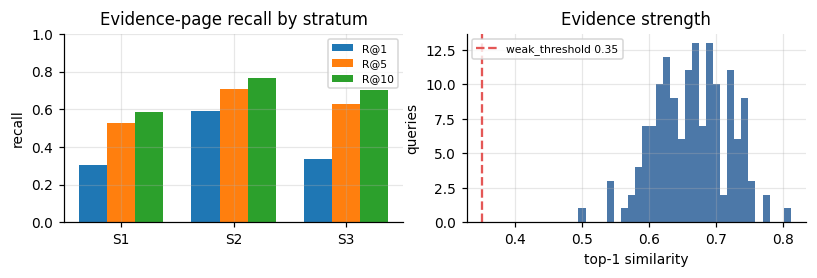

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(7.5, 2.6))
groups = [g for g in ("S1", "S2", "S3") if totals[g]]
w = 0.25
for i, k in enumerate(KS):
    ax[0].bar([x + i*w for x in range(len(groups))],
              [hits[k][g]/totals[g] for g in groups], width=w, label=f"R@{k}")
ax[0].set_xticks([x + w for x in range(len(groups))]); ax[0].set_xticklabels(groups)
ax[0].set_ylim(0, 1); ax[0].set_ylabel("recall"); ax[0].legend(fontsize=7)
ax[0].set_title("Evidence-page recall by stratum")

ax[1].hist(scores, bins=30, color="#4C78A8")
ax[1].axvline(cfg["retrieve"]["weak_threshold"], color="#E45756", ls="--",
              label=f"weak_threshold {cfg['retrieve']['weak_threshold']}")
ax[1].set_xlabel("top-1 similarity"); ax[1].set_ylabel("queries"); ax[1].legend(fontsize=7)
ax[1].set_title("Evidence strength")
plt.tight_layout(); plt.savefig(os.path.join(FIGS, "kb_retrieval.png")); plt.show()

## 4 · One retrieval that worked

In [8]:
example = next(
    ((q, got[:5]) for q, got in results
     if q["stratum"] == "S3" and got and set(q["page_ids"]) & set(got[0].page_ids)),
    None,
)
assert example, "no S3 query put its gold page first — report a different stratum"
q, got = example
print("QUERY")
print(" ", q["query"])
print("\nGOLD")
print("  answer      :", q["answer"])
print("  evidence    :", q["page_ids"], f"(stratum {q['stratum']}, {q['subimg_type']})")
print("\nTOP CHUNK RETURNED")
top = got[0]
print("  chunk id    :", top.id)
print("  page        :", top.page_ids)
print("  score       :", round(top.score, 4))
print("  RIGHT PAGE? :", "YES" if set(q["page_ids"]) & set(top.page_ids) else "no")
print("\n  text:")
print("   ", top.text[:700].replace("\n", "\n    "))
print("\nRANKING")
for i, c in enumerate(got, 1):
    mark = "*" if set(q["page_ids"]) & set(c.page_ids) else " "
    print(f"  {mark}{i}. {c.score:.4f}  {c.id}")

QUERY
  In the reduced confusion matrix, which two grey probability terms appear in the Ŷ=1 column, and what σ is given for XT in the mortgage example legend?

GOLD
  answer      : p^s_{01} and p^s_{11}; 30,000
  evidence    : ['econ/2405.09360/p008', 'econ/2405.09360/p006'] (stratum S3, ['image'])

TOP CHUNK RETURNED
  chunk id    : econ/2405.09360/p006#r01:figure/c000
  page        : ['econ/2405.09360/p006']
  score       : 0.7071
  RIGHT PAGE? : YES

  text:
    [figure] Figure 3: Confusion matrix in the reduced setting. The cases 00 and 10 are now collapsed to the case \(0\) (where \(\hat{Y}=0\)).

RANKING
  *1. 0.7071  econ/2405.09360/p006#r01:figure/c000
   2. 0.6859  econ/2405.09360/p002#r01:figure/c000
  *3. 0.6305  econ/2405.09360/p006#prose/c004
  *4. 0.6303  econ/2405.09360/p006#prose/c003
   5. 0.6204  econ/2405.09360/p007#prose/c002


## 5 · The worst failure we saw

Reported because naming failures is how A3 gets targeted. Two candidates are examined:
the worst-read page in the oracle, and a query whose gold evidence retrieval missed
entirely.

In [9]:
worst = max(rows, key=lambda x: x["cer"])
print("WORST-READ HELD-OUT PAGE")
print(f"  page      : {worst['page_id']}  (stratum {worst['stratum']}, "
      f"multicolumn={bool(worst['multicolumn'])})")
print(f"  CER       : {worst['cer']:.3f}   WER {worst['wer']:.3f}   token-F1 {worst['f1']:.3f}")
gold = next(x for x in labels if x["page_id"] == worst["page_id"])
pred = ocr_cache[worst["page_id"]]
print(f"\n  GOLD  ({len(gold['text'].split())} words):")
print("   ", gold["text"][:400].replace("\n", " "))
print(f"\n  NOUGAT ({len(pred.split())} words):")
print("   ", pred[:400].replace("\n", " "))

WORST-READ HELD-OUT PAGE
  page      : math/2412.17167/p002  (stratum S1, multicolumn=False)
  CER       : 0.902   WER 0.896   token-F1 0.188

  GOLD  (455 words):
    2 P. M. HAJAC AND Y. LIU ∗-homomorphism Op→Mk(Oq) can exist only if (p−1)k= (q−1)sfor some s∈N \ {0}. (1.1) Note that, in this more general setting, the number of standard generators of the source Cuntz algebra no longer has to match or exceed the number of standard generators of the target Cuntz algebra. On theotherhand, Cuntzalgebras aregraph C*-algebras [7], and awideclass ∗-homomorphisms betwe

  NOUGAT (220 words):
    Introduction Let \(\mathcal{C}\) be a finite graph and let \(\mathcal{C}\) be a finite graph. Let \(\mathcal{C}\) be a finite graph and let \(\mathcal{C}^{*}\) be a finite graph. Let \(\mathcal{C}^{*}\) be a finite graph and let \(\mathcal{C}^{*}\) be a finite graph. Let \(\mathcal{C}^{*}\) be a finite graph and let \(\mathcal{C}^{*}\) be a finite graph. Let \(\mathcal{C}^{*}\) be a finite graph a


In [10]:
misses = [
    (q, got) for q, got in results
    if not (set(q["page_ids"]) & {p for c in got for p in c.page_ids})
]

print(f"queries whose gold page never appeared in the top 10: {len(misses)}/{len(sample)}")
if misses:
    q, got = misses[0]
    print("\nEXAMPLE MISS")
    print("  query    :", q["query"][:150])
    print("  stratum  :", q["stratum"], q["subimg_type"])
    print("  gold page:", q["page_ids"])
    print("  top hit  :", got[0].id, round(got[0].score, 4))
    print("  text     :", got[0].text[:250].replace("\n", " "))
    print("\n  Read: a question phrased about what a figure SHOWS shares little surface")
    print("  vocabulary with the caption text that represents it, so a dense embedder")
    print("  ranks topically-similar prose above the region that holds the answer.")
    print("  This is what rerank (E6) and evidence-gated re-search exist to fix in A3.")

queries whose gold page never appeared in the top 10: 50/150

EXAMPLE MISS
  query    : In the second displayed equality, what scaling multiplies U0, and which variables inside G are multiplied by ψ?
  stratum  : S1 ['text']
  gold page: ['econ/2412.19024/p009']
  top hit  : q-fin/2401.05713/p011#prose/c000 0.6338
  text     : **Corollary 3.5**.: _For any \(t\in\{0,1,...,T\}\), the following equalities hold._  \[\operatorname*{ess\ sup}_{\mathcal{F}_{t}}(I_{\{\tau\geq t\}})=I_{\{ \widetilde{G}_{t}>0\}},\quad\text{and}\quad\operatorname*{ess\ inf}_{\mathcal{F }_{t}}(\mathrm

  Read: a question phrased about what a figure SHOWS shares little surface
  vocabulary with the caption text that represents it, so a dense embedder
  ranks topically-similar prose above the region that holds the answer.
  This is what rerank (E6) and evidence-gated re-search exist to fix in A3.


## 6 · Summary — the numbers that go in the form

In [11]:
print("SECTION 5 — EVIDENCE IT WORKS\n")
print(f"OCR quality      : CER {overall[1]:.3f} / token-F1 {overall[3]:.3f} "
      f"on {overall[0]} held-out pages")
for s in ("S1", "S2", "S3"):
    if s in per_stratum:
        a = per_stratum[s]
        print(f"                   {s}: CER {a[1]:.3f}  token-F1 {a[3]:.3f}  (n={a[0]})")
print()
print(f"Index statistics : {meta['n_chunks']:,} chunks | dim {meta['dim']} | "
      f"{meta['index_type']} | {idx_bytes/2**20:.1f} MB")
print(f"                   {indexed_pages:,}/{corpus_pages:,} pages "
      f"({100*indexed_pages/corpus_pages:.1f}%), {meta['n_words']:,}/{corpus_words:,} words")
print()
print(f"Retrieval        : R@1 {hits[1]['ALL']/totals['ALL']:.3f}  "
      f"R@5 {hits[5]['ALL']/totals['ALL']:.3f}  R@10 {hits[10]['ALL']/totals['ALL']:.3f} "
      f"on {totals['ALL']} sampled queries")
for s in ("S1", "S2", "S3"):
    if totals[s]:
        print(f"                   {s}: R@5 {hits[5][s]/totals[s]:.3f}  (n={totals[s]})")
print()
print(f"Worst failure    : {worst['page_id']} read at CER {worst['cer']:.3f}; "
      f"{len(misses)}/{len(sample)} queries missed their gold page at k=10")

SECTION 5 — EVIDENCE IT WORKS

OCR quality      : CER 0.300 / token-F1 0.866 on 18 held-out pages
                   S1: CER 0.356  token-F1 0.763  (n=6)
                   S2: CER 0.308  token-F1 0.892  (n=6)
                   S3: CER 0.235  token-F1 0.943  (n=6)

Index statistics : 5,240 chunks | dim 768 | faiss:flat | 15.4 MB
                   1,818/1,823 pages (99.7%), 817,614/788,265 words

Retrieval        : R@1 0.353  R@5 0.600  R@10 0.667 on 150 sampled queries
                   S1: R@5 0.528  (n=53)
                   S2: R@5 0.706  (n=17)
                   S3: R@5 0.625  (n=80)

Worst failure    : math/2412.17167/p002 read at CER 0.902; 50/150 queries missed their gold page at k=10
